# Test fit (LV / LSV via pybind)

**Market JSON:** [`data/pricing_json_schema.yaml`](../../data/pricing_json_schema.yaml) (`market_snapshot` section).

**Build:**
```bash
cmake --build build-std --target pricing_engine_py
```

Book MC pricing: [`pricing_from_json.ipynb`](pricing_from_json.ipynb).

## How to use this notebook

1. Build `pricing_engine_py`; restart the kernel after a rebuild .
2. Set parameters in the first code cell (`MARKET_JSON`, `MC_SAMPLES`, `MC_THREADS`).
3. Plots compare market vs LV and LV vs LSV on the verify grid.


## Parameters (first code cell)

| Knob | Role |
|------|------|
| `MARKET_JSON` | `market_snapshot.json` path |
| `MC_SAMPLES` | Paths for LSV-LV comparison|
| `MC_THREADS` | OpenMP workers (written to `OMP_NUM_THREADS` before import; C++ default 6 if unset) |
| `KMP_BLOCKTIME` | ms worker threads spin before sleeping at barriers (set to `50`); removes the fixed ~120 ms/sim overhead of macOS `libomp` and speeds up large runs too |

## Output

- Step 1: `asof`, spot, vol grid size (`strikes × expiries`).
- Step 2: static-arbitrage check on a discrete grid and check that the calibration error (MAE) at extreme strikes and maturities does not exceed 50 bp.
- Step 3: `verify_lv_bs_consistency`, Local Volatility model implied volatlity against market implied volatility
- Step 4: Dupire tabulated σ_LV grid dimensions + 3D surface and maturity slices.
- Step 5: `verify_lsv_mc_vs_lv_fd`, Local Stochastic Volatility against Local Volatility on model implied volatlity
- Plots: smile slices by expiry (market vs LV; LV vs LSV).

## Constraints

- Input: `market_snapshot.json`.
- Dates: ISO `YYYY-MM-DD`. Market tenors are ACT/365 year fractions (`asof + round(365·T)` calendar days). `asof` is the calendar anchor.
- Vol surface: long-format arrays must form a **full** strike × expiry matrix (no missing points).
- Step 5: requires `calibration()` first (Bergomi `k/nu/rho` come from the market JSON); large `MC_SAMPLES` needs enough RAM/time.
- Thread count: after changing `MC_THREADS`, Restart Kernel.



In [37]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# OpenMP workers for verify_lsv_mc_vs_lv_fd (must be set before import pricing_engine)
MC_THREADS = 6
os.environ["OMP_NUM_THREADS"] = str(MC_THREADS)
os.environ["KMP_BLOCKTIME"] = "50"

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent.parent
elif not (REPO / "CMakeLists.txt").exists():
    for p in REPO.parents:
        if (p / "CMakeLists.txt").exists():
            REPO = p
            break

BUILD_DIR = REPO / "build-std"
sys.path.insert(0, str(BUILD_DIR))

for name in list(sys.modules):
    if name == "pricing_engine" or name.startswith("pricing_engine."):
        del sys.modules[name]

import pricing_engine as pe

_REQUIRED = ("verify_lv_bs_consistency", "fixed_lv_x_tabulated_grid", "verify_lsv_mc_vs_lv_fd")
_missing = [m for m in _REQUIRED if not hasattr(pe.PricingContext, m)]
if _missing:
    raise RuntimeError(
        f"Rebuild pricing_engine_py (missing {_missing}). "
        "Restart kernel after: cmake --build build-std --target pricing_engine_py"
    )

print(f"pricing_engine: {pe.__file__}")

MARKET_JSON = REPO / "data" / "market_snapshot.json"
MC_SAMPLES = 2_000_000
SMILE_SKIP_TENORS = (1.5, 4.0)


pricing_engine: /Users/martino/Desktop/Pricing_Engine/build-std/pricing_engine.cpython-314-darwin.so


In [38]:
def print_step(step: int, title: str) -> None:
    bar = "─" * 56
    print(f"\n{bar}\n  {step} — {title}\n{bar}")


def summarize_iv_fit(rows, *, err_attr="abs_err_iv_bp", label=""):
    """Print mean/median/max |Δσ| in bp and coverage within thresholds."""
    errs = np.asarray(
        [getattr(r, err_attr) for r in rows if np.isfinite(getattr(r, err_attr))],
        dtype=float,
    )
    prefix = f"{label}: " if label else ""
    print(f"{prefix}grid points: {len(errs)}")
    if errs.size == 0:
        print(f"{prefix}no finite IV errors")
        return
    print(
        f"{prefix}|Δσ| (bp): mean={np.mean(errs):.2f}  median={np.median(errs):.2f}  "
        f"rmse={np.sqrt(np.mean(errs**2)):.2f}  p90={np.percentile(errs, 90):.2f}  "
        f"p95={np.percentile(errs, 95):.2f}  max={np.max(errs):.2f}"
    )
    for thr in (10.0, 25.0, 50.0):
        frac = 100.0 * np.mean(errs <= thr)
        print(f"{prefix}  within {thr:.0f} bp: {frac:.1f}%")


def plot_smiles_by_maturity(rows, ctx, y_a, y_b, label_a, label_b, suptitle,
                            skip_tenors=SMILE_SKIP_TENORS):
    from collections import defaultdict

    def skipped(t):
        return any(abs(t - s) < 0.08 for s in skip_tenors)

    by_expiry = defaultdict(list)
    for r in rows:
        if skipped(r.tenor_years):
            continue
        by_expiry[r.expiry].append(r)
    expiries = sorted(by_expiry, key=lambda e: by_expiry[e][0].tenor_years)

    n = len(expiries)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 2.8 * nrows), squeeze=False)

    spot = ctx.market_summary().spot
    for i, exp in enumerate(expiries):
        ax = axes[i // ncols][i % ncols]
        pts = sorted(by_expiry[exp], key=lambda r: r.strike_s)
        t = pts[0].tenor_years
        m = [p.strike_s / spot for p in pts] if spot > 0.0 else [p.strike_s for p in pts]
        ax.plot(m, [getattr(p, y_a) for p in pts], "o-", ms=3, lw=1, label=label_a)
        ax.plot(m, [getattr(p, y_b) for p in pts], "s-", ms=3, lw=1, label=label_b)
        ax.set_title(f"T={t:.2f}y")
        ax.set_xlabel(r"$K/S$")
        ax.grid(True, alpha=0.3)
        if i % ncols == 0:
            ax.set_ylabel("implied vol")
    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].axis("off")

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(suptitle, y=1.06)
    plt.tight_layout()
    plt.show()


def plot_fixed_lv_x_tabulated_grid(grid):
    """Dupire tabulated fixed LV in X (regular grid used by FixedLocalVolSurface)."""
    t = np.array(grid.tenor_years)
    kx = np.array(grid.kx)
    z = np.array(grid.sigma)
    if z.shape != (len(kx), len(t)):
        raise ValueError(f"unexpected sigma shape {z.shape}, expected ({len(kx)}, {len(t)})")

    extrap_note = (
        f"Dupire tabulated grid ({len(kx)} kx × {len(t)} T) — σ_LV stored for FD/MC. "
        "Outside this rectangle: constant extrapolation in T and kx."
    )

    kx_mesh, t_mesh = np.meshgrid(kx, t, indexing="ij")
    fig = plt.figure(figsize=(11, 6.8))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(kx_mesh, t_mesh, z, cmap="viridis", linewidth=0, antialiased=True)
    ax.set_title("Fixed local vol in X — Dupire tabulated grid")
    ax.set_xlabel("kx")
    ax.set_ylabel("T (years)")
    ax.set_zlabel("sigma_loc_X")
    fig.colorbar(surf, ax=ax, shrink=0.7, pad=0.1, label="sigma_loc_X")
    fig.text(0.5, 0.01, extrap_note, ha="center", fontsize=9, style="italic")
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

    n_slices = min(9, len(t))
    slice_idx = np.unique(np.round(np.linspace(0, len(t) - 1, n_slices)).astype(int))
    n = len(slice_idx)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 2.8 * nrows), squeeze=False)

    for i, j in enumerate(slice_idx):
        ax = axes[i // ncols][i % ncols]
        ax.plot(kx, z[:, j], "-", lw=1, color="C0")
        ax.set_title(f"T={t[j]:.2f}y")
        ax.set_xlabel("kx")
        ax.grid(True, alpha=0.3)
        if i % ncols == 0:
            ax.set_ylabel("sigma_loc_X")
    for k in range(n, nrows * ncols):
        axes[k // ncols][k % ncols].axis("off")

    fig.suptitle("Fixed LV in X — slices (Dupire tabulated grid)", y=1.02)
    plt.tight_layout()
    plt.show()


In [39]:
market = json.loads(MARKET_JSON.read_text())
ctx = pe.PricingContext.from_tables(**market)
summary = ctx.market_summary()

print_step(1, "Market data")
print(f"asof={summary.asof}  spot={summary.spot:.2f}")
print(f"vol grid: {len(summary.strikes)} strikes × {len(summary.expiries)} expiries")



────────────────────────────────────────────────────────
  1 — Market data
────────────────────────────────────────────────────────
asof=2025-12-1  spot=8097.00
vol grid: 15 strikes × 11 expiries


In [40]:
print_step(2, "LV calibration")
ctx.preprocessing()
ctx.calibration(run_validation=False)

arb = ctx.check_static_arbitrage()
print("Static arbitrage:", "PASS" if arb.all_passed() else "FAIL")



────────────────────────────────────────────────────────
  2 — LV calibration
────────────────────────────────────────────────────────
Static arbitrage: PASS


In [41]:
print_step(3, "verify_LV_BS_consistency")
lv_verify_rows = ctx.verify_lv_bs_consistency()
summarize_iv_fit(lv_verify_rows, label="market vs LV")



────────────────────────────────────────────────────────
  3 — verify_LV_BS_consistency
────────────────────────────────────────────────────────
market vs LV: grid points: 137
market vs LV: |Δσ| (bp): mean=10.07  median=2.98  rmse=29.80  p90=15.97  p95=30.65  max=207.63
market vs LV:   within 10 bp: 83.2%
market vs LV:   within 25 bp: 94.2%
market vs LV:   within 50 bp: 96.4%



────────────────────────────────────────────────────────
  4 — Fixed LV surface in X (Dupire tabulated grid)
────────────────────────────────────────────────────────
tabulated grid: 200 kx × 120 T  (kx ∈ [0.3145, 2.102], T ∈ [0.0822, 10] y)


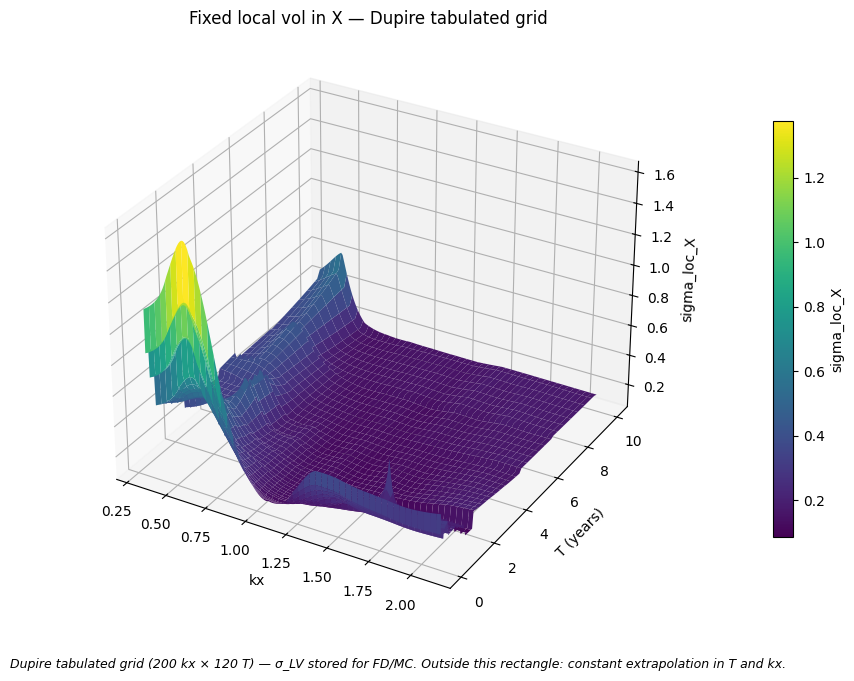

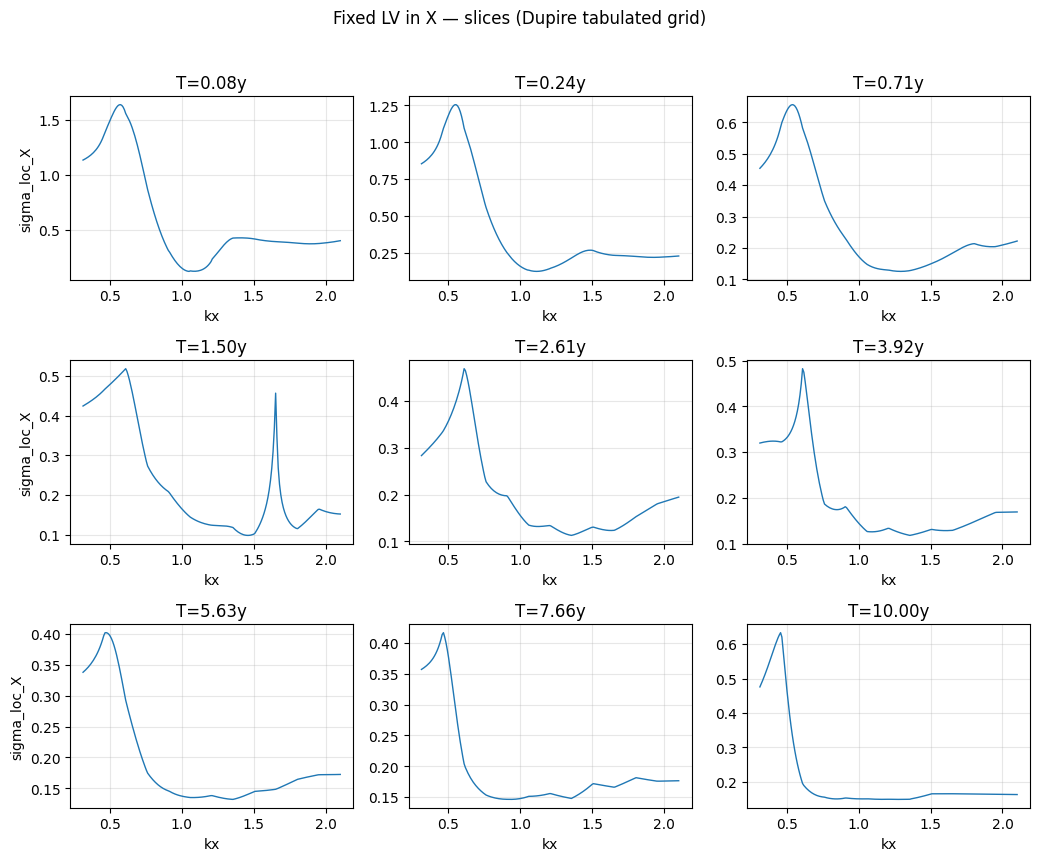

In [42]:
print_step(4, "Fixed LV surface in X (Dupire tabulated grid)")
lv_x_tab = ctx.fixed_lv_x_tabulated_grid()
print(
    f"tabulated grid: {len(lv_x_tab.kx)} kx × {len(lv_x_tab.tenor_years)} T  "
    f"(kx ∈ [{lv_x_tab.kx[0]:.4g}, {lv_x_tab.kx[-1]:.4g}], "
    f"T ∈ [{lv_x_tab.tenor_years[0]:.3g}, {lv_x_tab.tenor_years[-1]:.3g}] y)"
)
plot_fixed_lv_x_tabulated_grid(lv_x_tab)


In [43]:
print_step(5, "LSV vs LV: verify_lsv_mc_vs_lv_fd")
# Bergomi params are market inputs (bergomi_k/nu/rho in the market JSON); no LSV calibration step.
summary = ctx.market_summary()
print(f"bergomi: k={summary.bergomi_k}  nu={summary.bergomi_nu}  rho={summary.bergomi_rho}")

lsv_verify_rows = ctx.verify_lsv_mc_vs_lv_fd(mc_samples=MC_SAMPLES)
summarize_iv_fit(lsv_verify_rows, label="LV vs LSV")



────────────────────────────────────────────────────────
  5 — LSV vs LV: verify_lsv_mc_vs_lv_fd
────────────────────────────────────────────────────────
bergomi: k=2.0  nu=1.0  rho=-0.7
LV vs LSV: grid points: 137
LV vs LSV: |Δσ| (bp): mean=7.30  median=1.45  rmse=16.04  p90=26.85  p95=45.71  max=67.94
LV vs LSV:   within 10 bp: 83.2%
LV vs LSV:   within 25 bp: 89.1%
LV vs LSV:   within 50 bp: 97.1%


## Plots


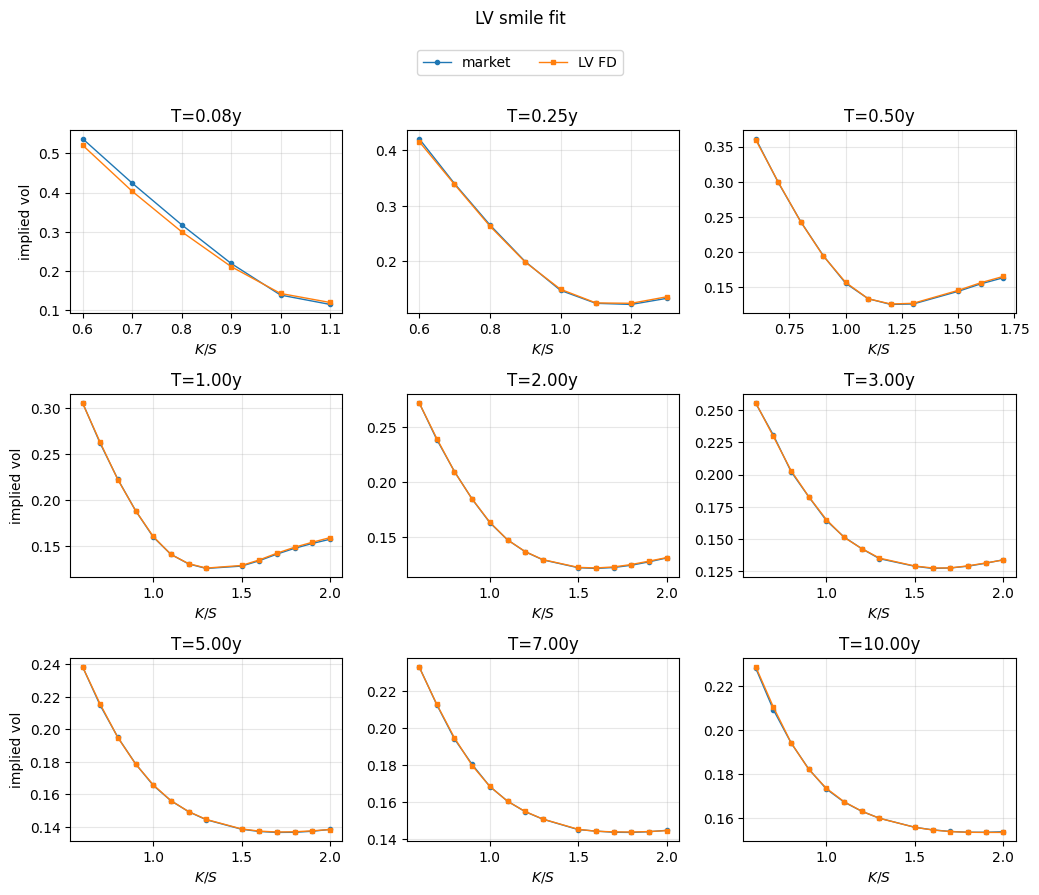

In [44]:
plot_smiles_by_maturity(
    lv_verify_rows,
    ctx,
    y_a="sigma_market_s",
    y_b="sigma_lv_s",
    label_a="market",
    label_b="LV FD",
    suptitle="LV smile fit",
)


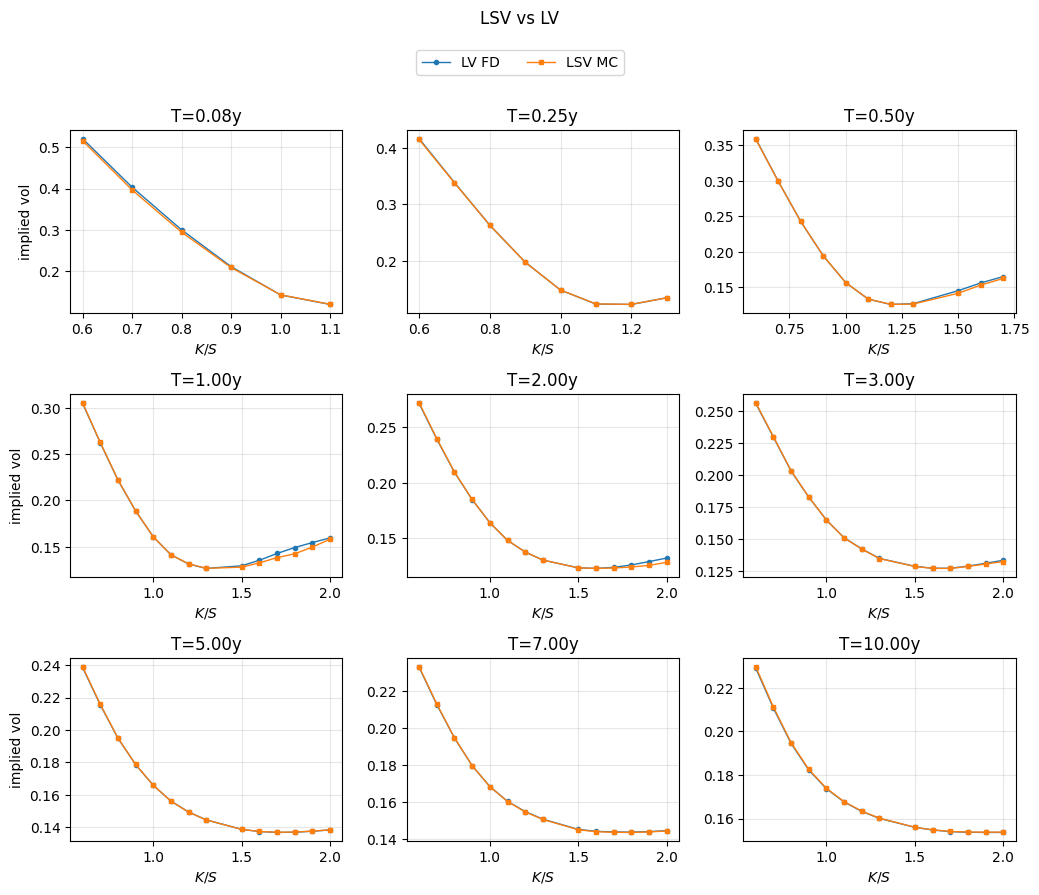

In [45]:
tenor_by_expiry = {r.expiry: r.tenor_years for r in lv_verify_rows}

class LsvIvPoint:
    __slots__ = ("expiry", "tenor_years", "strike_s", "iv_lv_s", "iv_lsv_s")

    def __init__(self, r):
        self.expiry = r.expiry
        self.strike_s = r.strike_s
        self.tenor_years = tenor_by_expiry.get(r.expiry, 0.0)
        self.iv_lv_s = r.iv_lv_s
        self.iv_lsv_s = r.iv_lsv_s

lsv_iv_points = [
    LsvIvPoint(r) for r in lsv_verify_rows
    if np.isfinite(r.iv_lv_s) and np.isfinite(r.iv_lsv_s)
]

plot_smiles_by_maturity(
    lsv_iv_points,
    ctx,
    y_a="iv_lv_s",
    y_b="iv_lsv_s",
    label_a="LV FD",
    label_b="LSV MC",
    suptitle="LSV vs LV",
)
